In [1]:
from src.QC import *
from src.plotting_functions import *
pio.renderers.default = "png"


hme1_1 = pd.read_csv("../../Experiment/hme1_1/Data/Processed/20260709_hTERT_HEM1_1_processed_phPlus.tsv", sep="\t", low_memory=False) #.fillna(0)
hme1_2 = pd.read_csv("../../Experiment/hme1_2/Data/Processed/20260709_hTERT_HEM1_2_processed_phPlus.tsv", sep="\t", low_memory=False)
hek_1 = pd.read_csv("../../Experiment/hek_1/Data/Processed/20260709_HEK293T_processed_phPlus.tsv", sep="\t", low_memory=False)
hme1_mutants = pd.read_csv("../../Experiment/hme1_mutants_test/Data/Processed/20260709_hTERT_HME1_mutants_processed_phPlus_filtered.tsv", sep="\t", low_memory=False)

In [2]:
TMT_plex_sample = hme1_1[['site',
                 'n:reps',
                 'WT_raw:abs_EGF_starve_r1',
                 'WT_raw:abs_EGF_starve_r2',
                 'WT_raw:abs_EGF_starve_r3',
                 'WT_raw:abs_EGF_starve_r4']]

# MSMS data quality check

## Value missingness and counts

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Missing values per sample'}, xlabel='Sample', ylabel='% missing // zero values'>)

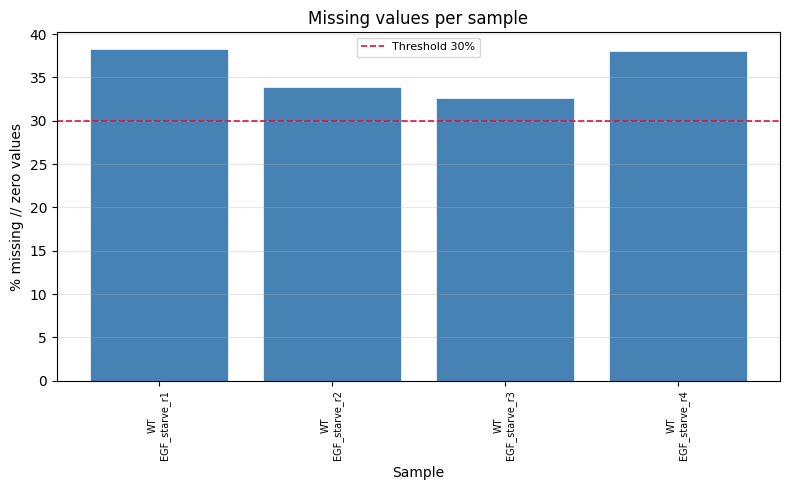

In [5]:
missing_values_per_sample(
    TMT_plex_sample,
    cell_lines=["WT"], #, "BRAFS151A", "GAB1Y259A"],
    conditions=["_EGF_", "_INS_","_EGFnINS_"],
    data_type="raw:abs",
    missing_threshold=0.30,
    figsize=None,
    title="Missing values per sample",
    ax=None,
)

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Detected peptides per sample'}, xlabel='Sample', ylabel='Number of detected peptides'>)

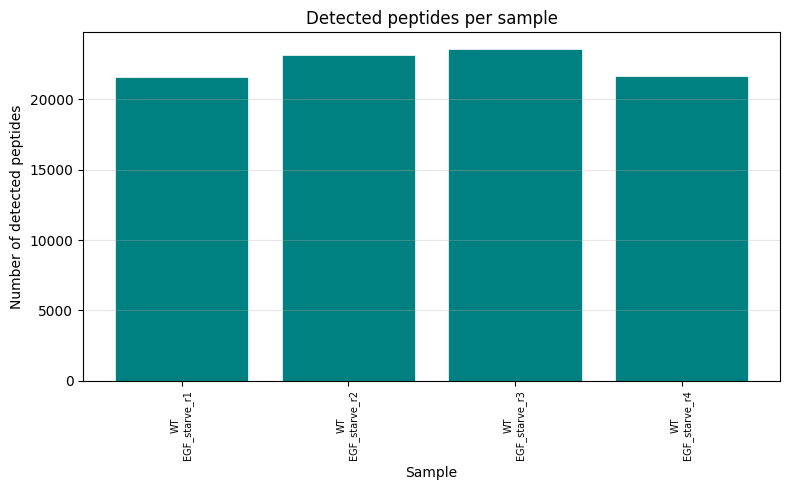

In [6]:
peptide_count_per_sample(
    TMT_plex_sample,
    cell_lines=["WT", "BRAFS151A", "GAB1Y259A"],
    conditions=["_EGF_"], # "_INS_","_EGFnINS_"],
    data_type="raw:abs",
    missing_value=0.0,
    figsize=None,
    title="Detected peptides per sample",
    ax=None,
)

Replicate detection summary (35002 sites):
  1 replicate : 28.0%
  2 replicates: 20.1%
  3 replicates: 18.8%
  4 replicates: 33.2%


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Replicate count distribution'}, xlabel='Number of replicates detected', ylabel='Number of peptides'>)

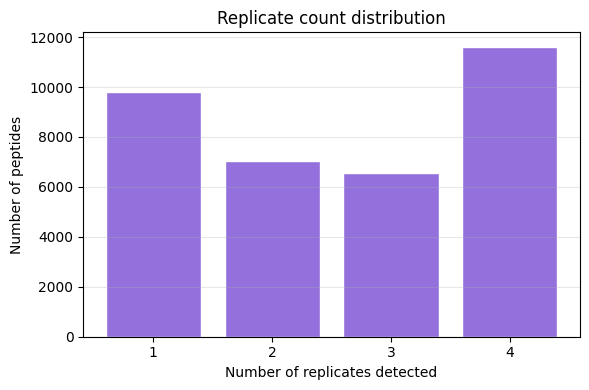

In [7]:
nreps_distribution(
    TMT_plex_sample,
    nreps_col="n:reps",
    figsize=(6, 4),
    title="Replicate count distribution",
    ax=None,
)

(<Figure size 400x1000 with 1 Axes>,
 <Axes: title={'center': 'Replicate detection map'}, ylabel='35002 sites'>)

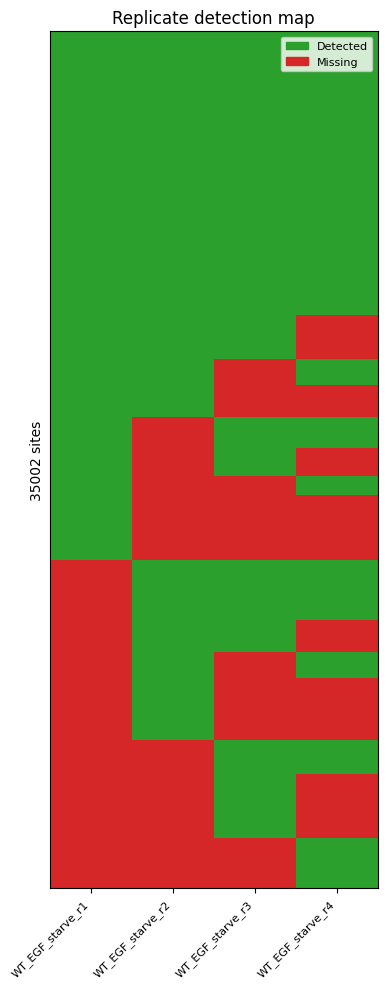

In [8]:
replicate_detection_map(
    TMT_plex_sample,
    cell_lines=["WT"], #, "BRAFS151A", "GAB1Y259A"],
    conditions=["_EGF_"], #, "_INS_","_EGFnINS_"],
    data_type="raw:abs",
    missing_value=0.0,
    figsize=None,
    title="Replicate detection map",
    ax=None,
)

## Intensity distribution

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Intensity distribution per sample'}, xlabel='log2 intensity', ylabel='Density'>)

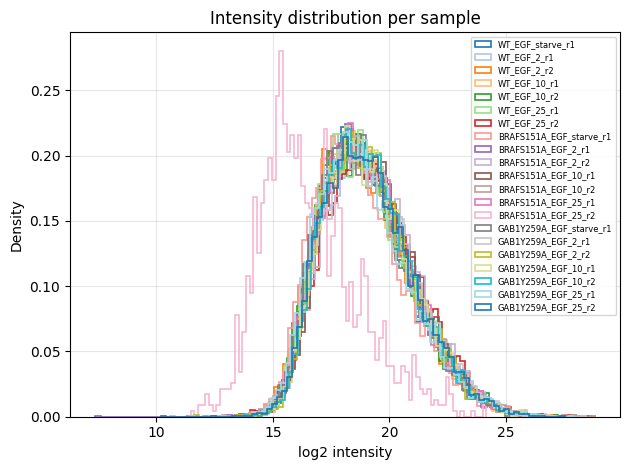

In [81]:
intensity_distribution(
    hme1_mutants,
    cell_lines=["WT", "BRAFS151A", "GAB1Y259A"],
    conditions=["_EGF_"], #, "_INS_","_EGFnINS_"],
    data_type="log2:abs",
    log_transform= False,
    figsize=None,
    title="Intensity distribution per sample",
    ax=None,
)

## CV variance

/Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/src/QC.py:518: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'CV distribution per timepoint'}, xlabel='Condition / timepoint', ylabel='CV (%)'>)

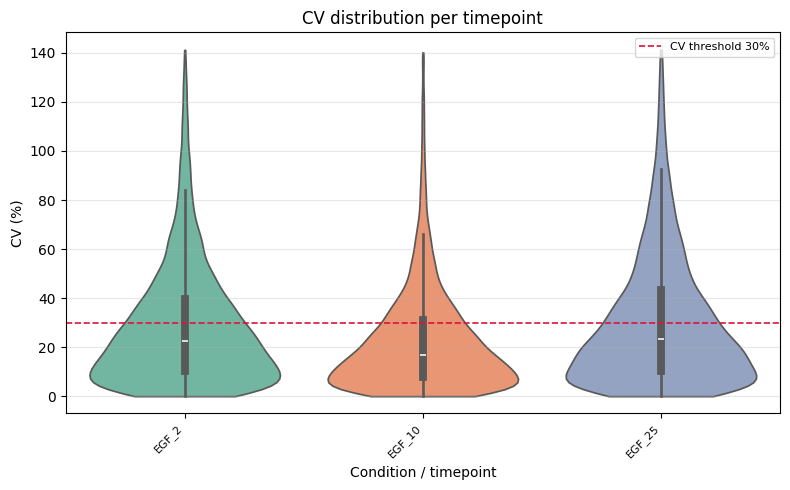

In [86]:
cv_distribution(
    hme1_mutants,
    cell_lines=["WT"], #"BRAFS151A", "GAB1Y259A"],
    conditions=["_EGF_"], #, "_INS_","_EGFnINS_"],
    data_type="raw:cv",
    cv_threshold=30.0,
    figsize=None,
    title="CV distribution per timepoint",
    ax=None,
)

## PCA of conditions

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


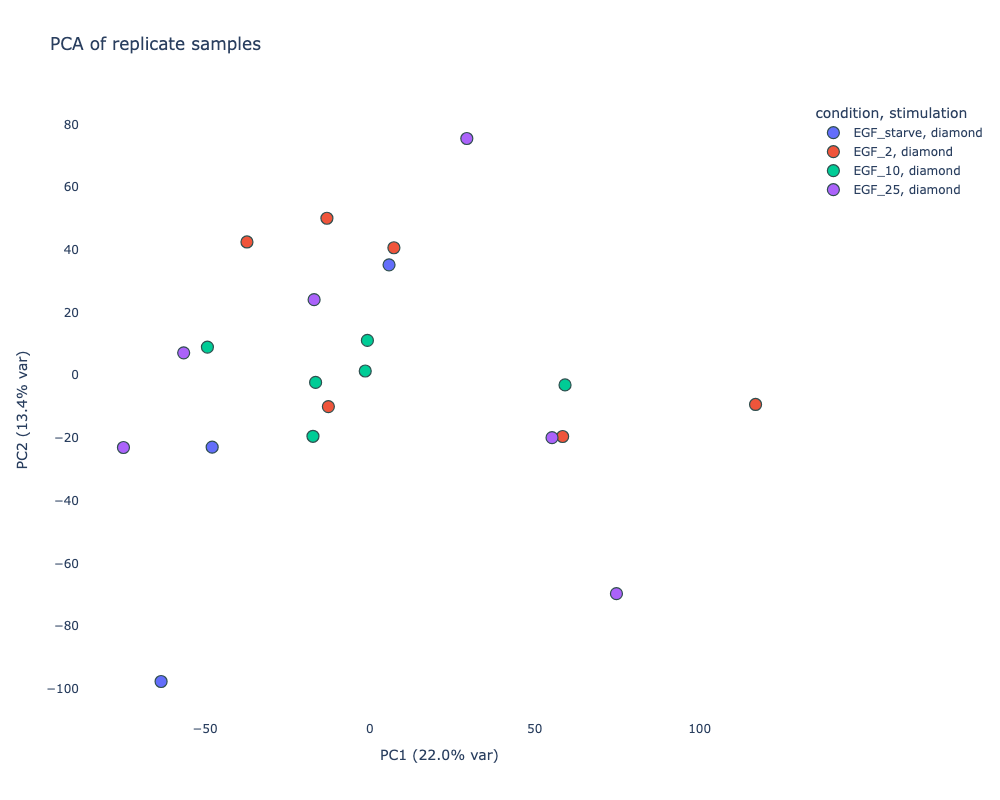

In [87]:
fig_scatter, fig_variance, pca_df = pca_plot_interactive(
                                                        hme1_mutants,
                                                        cell_lines=["WT", "BRAFS151A", "GAB1Y259A"],
                                                        conditions=["_EGF_", "_INS_","_EGFnINS_"],
                                                        data_type="log2:abs",
                                                        n_components=10,
                                                        impute=True,
                                                        impute_method="mean",
                                                        color_by="condition", #condition  cell_line
                                                        figsize=(1000, 800),
                                                        title="PCA of replicate samples",
                                                    )
fig_scatter.show()

## UMAP of conditions — read before interpreting

**For checking that replicates of a timepoint group together, use the PCA above, not the UMAP below.**

The `full` and `starve` timepoints are duplicated across the EGF / INS / EGFnINS conditions (they are the same physical samples, repeated only for convenient data handling). In **PCA** these duplicates overlap exactly — PCA is a deterministic linear projection, so identical feature vectors map to the same coordinate. In **UMAP** they appear **separated**: UMAP is a stochastic, graph-based force-directed layout where every sample is a separate node, and its repulsion term pushes even identical points apart regardless of `random_state`. That separation is an algorithm artifact, **not** a data or imputation problem.

So: use **PCA** for replicate-agreement and outlier QC. Treat this sample-level UMAP as exploratory only. UMAP's real value is at the **site level** (see the site-level UMAP further down), where its non-linear neighborhood-preservation helps reveal phosphosite response groups. See `QC_notes.md` for the full PCA vs UMAP comparison.


/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


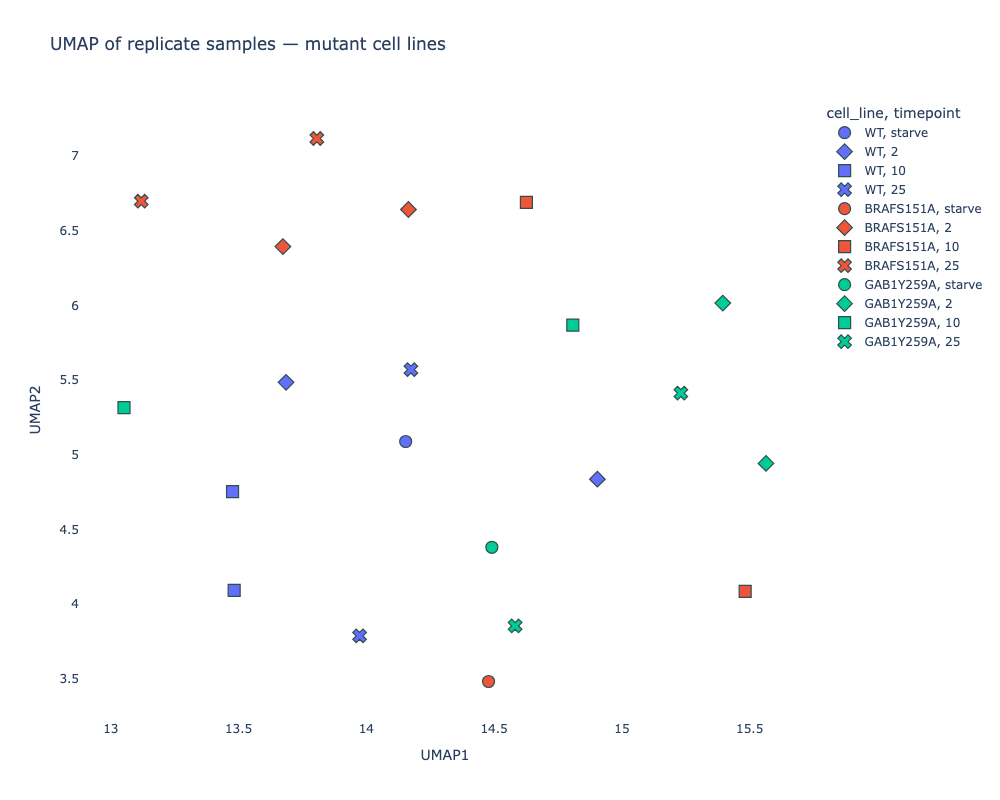

In [90]:
fig, umap = umap_plot_interactive(hme1_mutants,
                                  cell_lines=["WT", "BRAFS151A", "GAB1Y259A"],
                                  conditions=["_EGF_"], #,"_INS_","_EGFnINS_"],
                                  data_type="log2:abs",
                                  impute=True,
                                  impute_method="mean",
                                  n_neighbors=15,
                                  min_dist=0.1,
                                  random_state=42,
                                  color_by="cell_line", # "timepoint"  "cell_line"
                                  symbol_by="timepoint", # "cell_line"
                                  figsize=(1000, 800),
                                  title="UMAP of replicate samples — mutant cell lines",)

fig.show()

## Distance between conditions (PCA centroids)

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


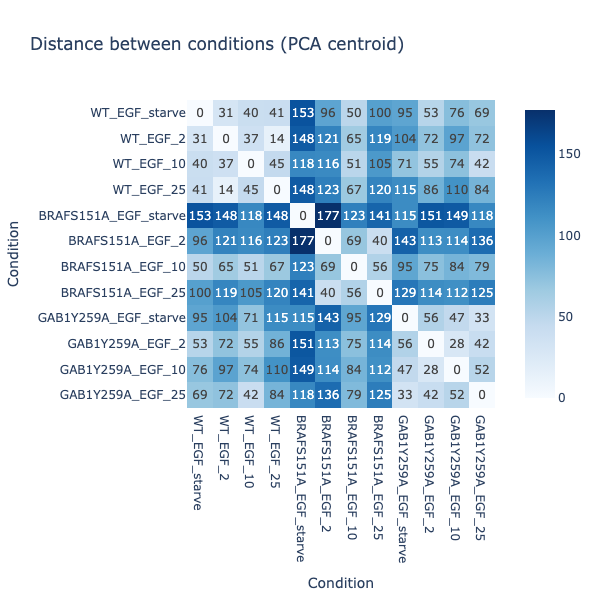

In [91]:
fig, dist_df, pca_df = pca_distance_heatmap(
                                            hme1_mutants,
                                            cell_lines=["WT", "BRAFS151A", "GAB1Y259A"],
                                            conditions=["_EGF_"], # "_INS_","_EGFnINS_"],
                                            data_type="log2:abs",
                                            impute=True,
                                            impute_method="mean",
                                            n_pca_components=3,
                                            centroid_stat="median",
                                            zmax=None,
                                            figsize=(600, 600),
                                            title="Distance between conditions (PCA centroid)",
                                        )
fig.show()

## UMAP of all samples
Not using individual replicates values

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


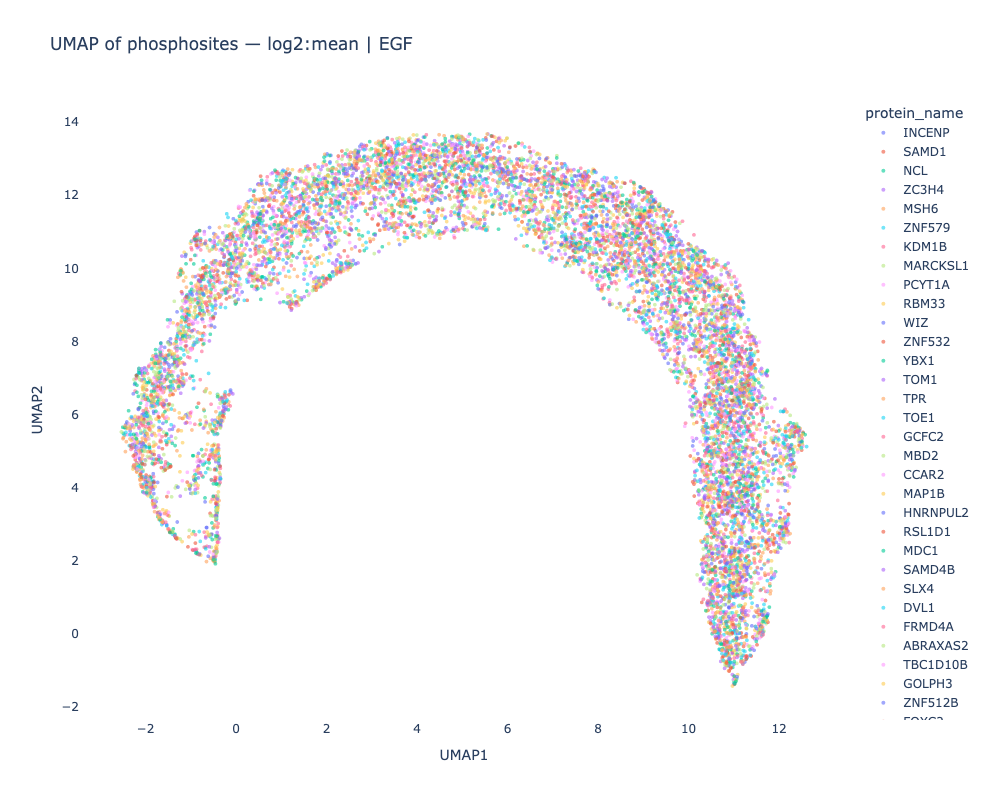

In [92]:
fig, ax = plot_sites_umap_interactive(hme1_mutants,
                                    cell_lines=["WT",  "BRAFS151A", "GAB1Y259A"],
                                    conditions=["_EGF_"], # "_INS_","_EGFnINS_"],
                                    data_type="log2:mean",
                                    exclude_full=True,
                                    color_col="protein_name", # None  "protein_name"
                                    hover_cols=None,
                                    n_neighbors=15,
                                    min_dist=0.1,
                                    random_state=42,
                                    figsize=(1000, 800),
                                    title=None,
)


fig.show()

# Datasets comparison

Compare phosphosite identity across the four raw MSMS datasets:
- `hek_1` — HEK293T experiment 1
- `hme1_1` — hTERT-HME1 experiment 1
- `hme1_2` — hTERT-HME1 experiment 2
- `hme1_mutants` — hTERT-HME1 mutant cell lines

Analyses:
- Venn diagrams of shared phosphosites
- Pairwise overlap summary table (n detected, n shared, % overlap)
- WT vs mutant overlap (critical for classifier transfer)

## Venn diagrams

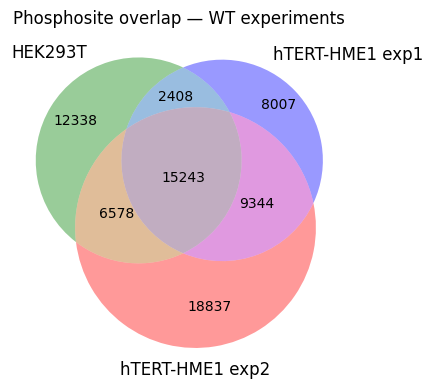

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Phosphosite overlap — WT experiments'}>)

In [61]:
# hTERT-HME1 replicate experiments + HEK293T
venn_diagrams(
    data_frames=[hek_1, hme1_1, hme1_2],
    labels=["HEK293T", "hTERT-HME1 exp1", "hTERT-HME1 exp2"],
    colors=["green", "blue", "red"],
    title="Phosphosite overlap — WT experiments",
    column_to_compare="site",
)

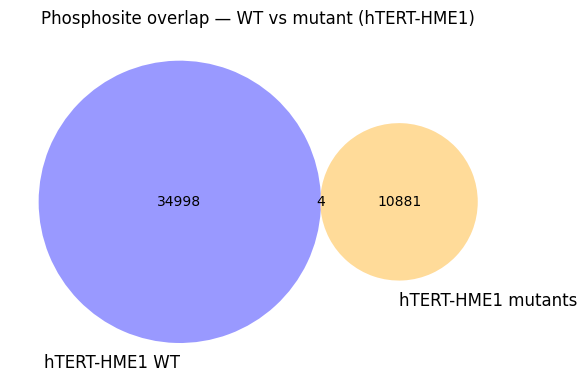

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Phosphosite overlap — WT vs mutant (hTERT-HME1)'}>)

In [62]:
# hTERT-HME1 WT (exp1) vs mutant dataset
# Critical for classifier transfer: only shared sites can be used to propagate cluster labels
venn_diagrams(
    data_frames=[hme1_1, hme1_mutants],
    labels=["hTERT-HME1 WT", "hTERT-HME1 mutants"],
    colors=["blue", "orange"],
    title="Phosphosite overlap — WT vs mutant (hTERT-HME1)",
    column_to_compare="site",
)

## Pairwise overlap summary

Quantitative table of n detected, n shared, and % overlap for every dataset pair.
`pct_A_in_B` = % of dataset A's sites also found in B (coverage from A's perspective).

In [63]:
overlap_summary(
    data_frames=[hek_1, hme1_1, hme1_2],
    labels=["HEK293T", "hTERT-HME1 exp1", "hTERT-HME1 exp2"],
    column_to_compare="site",
)

,dataset_A,dataset_B,n_A,n_B,n_overlap,pct_A_in_B,pct_B_in_A
0,HEK293T,hTERT-HME1 exp1,36567,35002,17651,48.3,50.4
1,HEK293T,hTERT-HME1 exp2,36567,50002,21821,59.7,43.6
2,hTERT-HME1 exp1,hTERT-HME1 exp2,35002,50002,24587,70.2,49.2
